In [1]:
import torch
import torch.nn.functional as F
from urllib.request import urlopen

url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
with urlopen(url) as response:
    words = response.read().decode("utf-8").splitlines()

chars = sorted(set("".join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi["."] = 0
itos = {i: ch for ch, i in stoi.items()}

In [2]:
block_size = 3
X, Y = [], []

word = words[0]
context = [0] * block_size

for ch in word + ".":
    ix = stoi[ch]

    X.append(context)
    Y.append(ix)

    print("".join(itos[i] for i in context), "→", ch)
    context = context[1:] + [ix]

X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)

print("X:", X, X.shape)
print("Y:", Y, Y.shape)

... → e
..e → m
.em → m
emm → a
mma → .
X: tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]]) torch.Size([5, 3])
Y: tensor([ 5, 13, 13,  1,  0]) torch.Size([5])


In [3]:
C = torch.randn((27, 2))
emb = C[X]

print(f"C.shape: {C.shape}")
print(f"X.shape: {X.shape}")
print(f"emb.shape: {emb.shape}")

print("두 번째 입력의 ID:", X[1])
print("두 번째 입력의 벡터:", emb[1])


C.shape: torch.Size([27, 2])
X.shape: torch.Size([5, 3])
emb.shape: torch.Size([5, 3, 2])
두 번째 입력의 ID: tensor([0, 0, 5])
두 번째 입력의 벡터: tensor([[-0.7322,  0.9038],
        [-0.7322,  0.9038],
        [ 1.1912, -1.1759]])


In [4]:
flat = emb.view(emb.shape[0], 6)

print("before:", emb.shape)
print("after:", flat.shape)
print("first example:", flat[0])

before: torch.Size([5, 3, 2])
after: torch.Size([5, 6])
first example: tensor([-0.7322,  0.9038, -0.7322,  0.9038, -0.7322,  0.9038])


In [5]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

pre_activation = flat @ W1 + b1
h = torch.tanh(pre_activation)

print("가중합과 편향:", pre_activation.shape)
print("은닉층 출력:", h.shape)

가중합과 편향: torch.Size([5, 100])
은닉층 출력: torch.Size([5, 100])


In [6]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)

print("logits:", logits.shape)
print("target:", Y)
print("loss:", loss.item())

logits: torch.Size([5, 27])
target: tensor([ 5, 13, 13,  1,  0])
loss: 12.705901145935059


In [7]:
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad_(True)

In [8]:
emb = C[X]
flat = emb.flatten(start_dim=1)
h = torch.tanh(flat @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)

for p in parameters:
    p.grad = None

loss.backward()

for name, p in zip(["C", "W1", "b1", "W2", "b2"], parameters):
    print(name, p.grad.shape)

C torch.Size([27, 2])
W1 torch.Size([6, 100])
b1 torch.Size([100])
W2 torch.Size([100, 27])
b2 torch.Size([27])


In [9]:
before = loss.item()
learning_rate = 0.1

with torch.no_grad():
    for p in parameters:
        p -= learning_rate * p.grad

    emb = C[X]
    flat = emb.flatten(start_dim=1)
    h = torch.tanh(flat @ W1 + b1)
    logits = h @ W2 + b2
    after = F.cross_entropy(logits, Y).item()

print(f"before: {before}")
print(f"after: {after}")

before: 12.705901145935059
after: 8.664443969726562


In [10]:
lr = 0.1

for step in range(100):
    emb = C[X]
    flat = emb.flatten(start_dim=1)
    h = torch.tanh(flat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)

    for p in parameters:
        p.grad = None

    loss.backward()

    with torch.no_grad():
        for p in parameters:
            p -= lr * p.grad

    if step % 20 == 0:
        print(step, loss.item())

0 8.664443969726562
20 0.011448676697909832
40 0.006235672626644373
60 0.004330087918788195
80 0.0033268362749367952


In [11]:
with torch.no_grad():
    emb = C[X]
    flat = emb.flatten(start_dim=1)
    h = torch.tanh(flat @ W1 + b1)
    logits = h @ W2 + b2

    print("final loss:", F.cross_entropy(logits, Y).item())
    print("prediction:", logits.argmax(dim=1))
    print("target:", Y)

final loss: 0.0027047130279242992
prediction: tensor([ 5, 13, 13,  1,  0])
target: tensor([ 5, 13, 13,  1,  0])


In [12]:
def build_dataset(word_list):
    X, Y = [], []

    for word in word_list:
        context = [0] * block_size

        for ch in list(word) + ["."]:
            ix = stoi[ch]

            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)

    return X, Y


In [13]:
X_small, Y_small = build_dataset(["emma", "ava"])

print(X_small)
print(Y_small)
print(X_small.shape, Y_small.shape)

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1]])
tensor([ 5, 13, 13,  1,  0,  1, 22,  1,  0])
torch.Size([9, 3]) torch.Size([9])


In [14]:
import random


shuffled_words = words.copy()
random.Random(42).shuffle(shuffled_words)

n = len(shuffled_words)
train_end = n * 8 // 10
dev_end = n * 9 // 10

train_words = shuffled_words[:train_end]
dev_words = shuffled_words[train_end:dev_end]
test_words = shuffled_words[dev_end:]

In [15]:
Xtr, Ytr = build_dataset(train_words)
Xdev, Ydev = build_dataset(dev_words)
Xte, Yte = build_dataset(test_words)

print("train:", Xtr.shape, Ytr.shape)
print("dev:", Xdev.shape, Ydev.shape)
print("test:", Xte.shape, Yte.shape)

train: torch.Size([182625, 3]) torch.Size([182625])
dev: torch.Size([22655, 3]) torch.Size([22655])
test: torch.Size([22866, 3]) torch.Size([22866])


In [16]:
g_batch = torch.Generator().manual_seed(42)

batch_indices = torch.randint(
    0, Xtr.shape[0], (32,), generator=g_batch
)

Xbatch = Xtr[batch_indices]
Ybatch = Ytr[batch_indices]

print("선택한 번호:", batch_indices[:5])
print("입력:", Xbatch.shape)
print("정답:", Ybatch.shape)

print("첫 입력:", Xbatch[0])
print("첫 정답:", Ybatch[0])


선택한 번호: tensor([ 76542,  11942, 157126,   2164,    651])
입력: torch.Size([32, 3])
정답: torch.Size([32])
첫 입력: tensor([20, 25, 18])
첫 정답: tensor(5)


In [17]:
g_model = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, 2), generator=g_model)
W1 = torch.randn((6, 100), generator=g_model)
b1 = torch.randn(100, generator=g_model)
W2 = torch.randn((100, 27), generator=g_model)
b2 = torch.randn(27, generator=g_model)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad_(True)

In [18]:
emb = C[Xbatch]
flat = emb.flatten(start_dim=1)
h = torch.tanh(flat @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ybatch)

print("embedding:", emb.shape)
print("logits:", logits.shape)
print("initial batch loss:", loss.item())


embedding: torch.Size([32, 3, 2])
logits: torch.Size([32, 27])
initial batch loss: 17.3421688079834


In [19]:
lr = 0.1

for step in range(1000):
    batch_indices = torch.randint(
        0, Xtr.shape[0], (32,), generator=g_batch
    )
    Xbatch = Xtr[batch_indices]
    Ybatch = Ytr[batch_indices]

    emb = C[Xbatch]
    flat = emb.flatten(start_dim=1)
    h = torch.tanh(flat @ W1 + b1)
    logits = h @ W2 + b2

    for p in parameters:
        p.grad = None

    loss = F.cross_entropy(logits, Ybatch)
    loss.backward()

    with torch.no_grad():
        for p in parameters:
            p -= p.grad * lr

    if step % 100 == 0:
        print(step, loss.item())

0 17.7901668548584
100 4.878086566925049
200 2.951786994934082
300 3.2478911876678467
400 2.6897943019866943
500 2.820378303527832
600 2.8057241439819336
700 2.9028756618499756
800 2.3549323081970215
900 2.8749308586120605


In [20]:
with torch.no_grad():
    dev_emb = C[Xdev]
    dev_flat = dev_emb.flatten(start_dim=1)
    dev_h = torch.tanh(dev_flat @ W1 + b1)
    dev_logits = dev_h @ W2 + b2
    dev_loss = F.cross_entropy(dev_logits, Ydev)


print("dev logits:", dev_logits.shape)
print("dev loss:", dev_loss.item())

dev logits: torch.Size([22655, 27])
dev loss: 2.6882379055023193


In [21]:
with torch.no_grad():
    train_emb = C[Xtr]
    train_flat = train_emb.flatten(start_dim=1)
    train_h = torch.tanh(train_flat @ W1 + b1)
    train_logits = train_h @ W2 + b2
    train_loss = F.cross_entropy(train_logits, Ytr)


print("train logits:", train_logits.shape)
print("train loss:", train_loss.item())

train logits: torch.Size([182625, 27])
train loss: 2.6954843997955322


In [22]:
dev_before = dev_loss.item()
lr = 0.01

# train 데이터로 학습
for step in range(1000):
    batch_indices = torch.randint(
        0, Xtr.shape[0], (32,), generator=g_batch
    )
    Xbatch = Xtr[batch_indices]
    Ybatch = Ytr[batch_indices]

    emb = C[Xbatch]
    flat = emb.flatten(start_dim=1)
    h = torch.tanh(flat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ybatch)

    for p in parameters:
        p.grad = None

    loss.backward()

    with torch.no_grad():
        for p in parameters:
            p -= lr * p.grad

    if step % 100 == 0:
        print(step, loss.item())

# 학습이 끝난 뒤 dev 데이터로 평가
with torch.no_grad():
    dev_emb = C[Xdev]
    dev_flat = dev_emb.flatten(start_dim=1)
    dev_h = torch.tanh(dev_flat @ W1 + b1)
    dev_logits = dev_h @ W2 + b2
    dev_loss = F.cross_entropy(dev_logits, Ydev)

print("dev before:", dev_before)
print("dev after:", dev_loss.item())

0 2.7086236476898193


100 2.380824565887451
200 2.4864838123321533
300 2.4275200366973877
400 2.336048126220703
500 2.4389142990112305
600 2.4126720428466797
700 2.477017641067505
800 2.7221109867095947
900 2.4307873249053955
dev before: 2.6882379055023193
dev after: 2.562011480331421


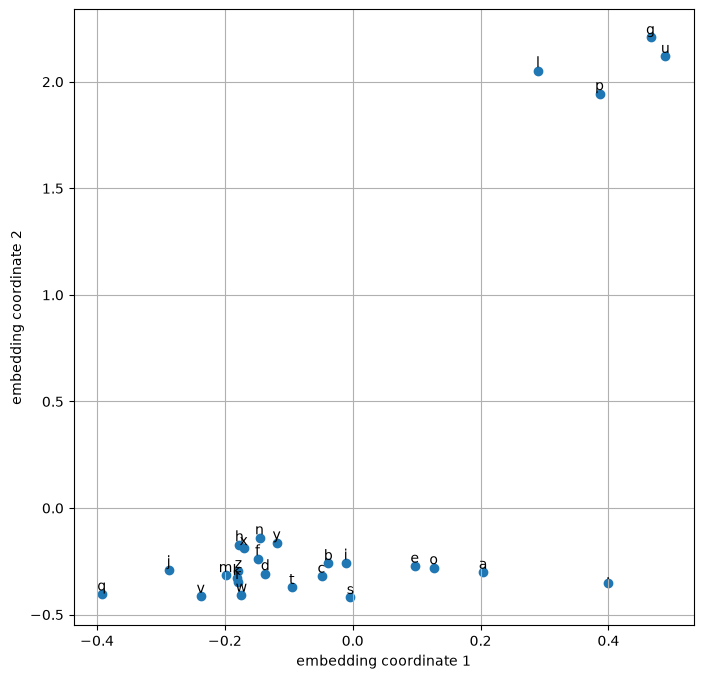

In [23]:
import matplotlib.pyplot as plt

coords = C.detach()

plt.figure(figsize=(8, 8))
plt.scatter(coords[:, 0], coords[:, 1])

for i in range(len(itos)):
    plt.text(
        coords[i, 0].item(),
        coords[i, 1].item(),
        itos[i],
        ha="center",
        va="bottom",
    )

plt.xlabel("embedding coordinate 1")
plt.ylabel("embedding coordinate 2")
plt.grid()
plt.show()

In [24]:
g_sample = torch.Generator().manual_seed(2147483647)

with torch.no_grad():
    for sample in range(5):
        context = [0] * block_size
        generated = []
        ended = False

        for step in range(30):
            x = torch.tensor([context], dtype=torch.long)  # (1, 3)
            emb = C[x]                                   # (1, 3, 2)
            flat = emb.flatten(start_dim=1)               # (1, 6)
            h = torch.tanh(flat @ W1 + b1)                 # (1, 100)
            logits = h @ W2 + b2                          # (1, 27)
            probs = torch.softmax(logits, dim=1)

            ix = torch.multinomial(
                probs, num_samples=1, generator=g_sample
            ).item()

            if ix == 0:
                ended = True
                break

            generated.append(itos[ix])
            context = context[1:] + [ix]

        print("".join(generated), "| 종료 문자 도달:", ended)

dex | 종료 문자 도달: True
malealleraila | 종료 문자 도달: True
kayha | 종료 문자 도달: True
molimitna | 종료 문자 도달: True
nrllaan | 종료 문자 도달: True


In [25]:
embedding_dim = 10
hidden_size = 200
g_large = torch.Generator().manual_seed(2147483647)

C_large = torch.randn((27, embedding_dim), generator=g_large)
W1_large = torch.randn(
    (block_size * embedding_dim, hidden_size), generator=g_large
)
b1_large = torch.randn(hidden_size, generator=g_large)
W2_large = torch.randn(
    (hidden_size, 27), generator=g_large
)
b2_large = torch.randn(27, generator=g_large)


parameters_large = [C_large, W1_large, b1_large, W2_large, b2_large]

for p in parameters_large:
    p.requires_grad_(True)

print("parameter count:", sum(p.numel() for p in parameters_large))

parameter count: 11897


In [26]:
emb_large = C_large[Xbatch]
flat_large = emb_large.flatten(start_dim=1)
h_large = torch.tanh(flat_large @ W1_large + b1_large)
logits_large = h_large @ W2_large + b2_large
loss_large = F.cross_entropy(logits_large, Ybatch)

print("embedding:", emb_large.shape)
print("flat:", flat_large.shape)
print("hidden:", h_large.shape)
print("logits:", logits_large.shape)
print("initial batch loss:", loss_large.item())

embedding: torch.Size([32, 3, 10])
flat: torch.Size([32, 30])
hidden: torch.Size([32, 200])
logits: torch.Size([32, 27])
initial batch loss: 25.059974670410156


In [27]:
lr_large = 0.1
g_batch_large = torch.Generator().manual_seed(42)

for step in range(1000):
    indices = torch.randint(
        0, Xtr.shape[0], (32,), generator=g_batch_large
    )

    emb_large = C_large[Xtr[indices]]
    flat_large = emb_large.flatten(start_dim=1)
    h_large = torch.tanh(flat_large @ W1_large + b1_large)
    logits_large = h_large @ W2_large + b2_large
    loss_large = F.cross_entropy(logits_large, Ytr[indices])

    for p in parameters_large:
        p.grad = None

    loss_large.backward()

    with torch.no_grad():
        for p in parameters_large:
            p -= lr_large * p.grad

    if step % 100 == 0:
        print(step, loss_large.item())

with torch.no_grad():
    emb_large = C_large[Xdev]
    flat_large = emb_large.flatten(start_dim=1)
    h_large = torch.tanh(flat_large @ W1_large + b1_large)
    logits_large = h_large @ W2_large + b2_large
    dev_loss_large = F.cross_entropy(logits_large, Ydev)

print("large model dev loss:", dev_loss_large.item())

0 28.234289169311523


100 10.705829620361328
200 7.301276206970215
300 5.14031982421875
400 6.825262069702148
500 5.297885417938232
600 3.349144458770752
700 3.661867618560791
800 4.780320167541504
900 4.230432033538818
large model dev loss: 3.8881330490112305


In [28]:
probe_parameters = [
    p.detach().clone().requires_grad_(True)
    for p in parameters_large
]

C_probe, W1_probe, b1_probe, W2_probe, b2_probe = probe_parameters

print([p.shape for p in probe_parameters])
print(C_probe is C_large)
print(torch.allclose(C_probe, C_large))

[torch.Size([27, 10]), torch.Size([30, 200]), torch.Size([200]), torch.Size([200, 27]), torch.Size([27])]
False
True


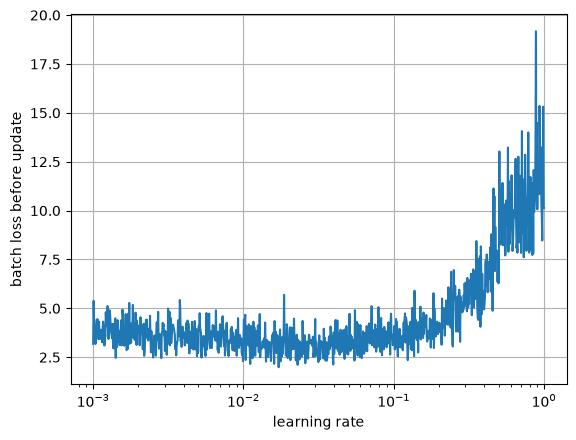

In [29]:
g_probe = torch.Generator().manual_seed(42)
lrs = 10 ** torch.linspace(-3, 0, 1000)
probe_losses = []

for lr in lrs:
    indices = torch.randint(
        0, Xtr.shape[0], (32,), generator=g_probe
    )

    emb = C_probe[Xtr[indices]]
    flat = emb.flatten(start_dim=1)
    h = torch.tanh(flat @ W1_probe + b1_probe)
    logits = h @ W2_probe + b2_probe
    loss = F.cross_entropy(logits, Ytr[indices])

    probe_losses.append(loss.item())

    for p in probe_parameters:
        p.grad = None

    loss.backward()

    with torch.no_grad():
        for p in probe_parameters:
            p -= p.grad * lr.item()

plt.plot(lrs.tolist(), probe_losses)
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("batch loss before update")
plt.grid()
plt.show()

In [31]:
dev_before_large = dev_loss_large.item()
lr_large = 0.01
g_batch_large = torch.Generator().manual_seed(42)

for step in range(1000):
    indices = torch.randint(
        0, Xtr.shape[0], (32,), generator=g_batch_large
    )

    emb_large = C_large[Xtr[indices]]
    flat_large = emb_large.flatten(start_dim=1)
    h_large = torch.tanh(flat_large @ W1_large + b1_large)
    logits_large = h_large @ W2_large + b2_large
    loss_large = F.cross_entropy(logits_large, Ytr[indices])

    for p in parameters_large:
        p.grad = None

    loss_large.backward()

    with torch.no_grad():
        for p in parameters_large:
            p -= lr_large * p.grad

    if step % 100 == 0:
        print(step, loss_large.item())

with torch.no_grad():
    emb_large = C_large[Xdev]
    flat_large = emb_large.flatten(start_dim=1)
    h_large = torch.tanh(flat_large @ W1_large + b1_large)
    logits_large = h_large @ W2_large + b2_large
    dev_loss_large = F.cross_entropy(logits_large, Ydev)

print("dev before:", dev_before_large)
print("dev after:", dev_loss_large.item())

0 2.6872541904449463
100 3.3601081371307373
200 3.066296100616455
300 2.292239189147949
400 3.42089581489563
500 2.9946560859680176
600 2.4011919498443604
700 2.6247620582580566
800 3.158270835876465
900 2.9998583793640137
dev before: 3.233107089996338
dev after: 3.1444075107574463


In [32]:
with torch.no_grad():
    train_emb_large = C_large[Xtr]
    train_flat_large = train_emb_large.flatten(start_dim=1)
    train_h_large = torch.tanh(
        train_flat_large @ W1_large + b1_large
    )
    train_logits_large = train_h_large @ W2_large + b2_large
    train_loss_large = F.cross_entropy(train_logits_large, Ytr)

print("train:", train_loss_large.item())
print("dev:", dev_loss_large.item())

train: 3.1557939052581787
dev: 3.1444075107574463


In [33]:
dev_before_large = dev_loss_large.item()
lr_large = 0.01

for step in range(10000):
    indices = torch.randint(
        0, Xtr.shape[0], (32,), generator=g_batch_large
    )

    emb_large = C_large[Xtr[indices]]
    flat_large = emb_large.flatten(start_dim=1)
    h_large = torch.tanh(flat_large @ W1_large + b1_large)
    logits_large = h_large @ W2_large + b2_large
    loss_large = F.cross_entropy(logits_large, Ytr[indices])

    for p in parameters_large:
        p.grad = None

    loss_large.backward()

    with torch.no_grad():
        for p in parameters_large:
            p -= lr_large * p.grad

    if step % 1000 == 0:
        print(step, loss_large.item())

with torch.no_grad():
    emb_large = C_large[Xdev]
    flat_large = emb_large.flatten(start_dim=1)
    h_large = torch.tanh(flat_large @ W1_large + b1_large)
    logits_large = h_large @ W2_large + b2_large
    dev_loss_large = F.cross_entropy(logits_large, Ydev)

print("dev before:", dev_before_large)
print("dev after:", dev_loss_large.item())

0 2.2569873332977295
1000 3.288222551345825
2000 2.5502607822418213
3000 2.3089895248413086
4000 3.0826644897460938
5000 2.572134256362915
6000 3.4056854248046875
7000 3.39426589012146
8000 2.5667784214019775
9000 2.962827205657959
dev before: 3.1444075107574463
dev after: 2.6941661834716797


In [34]:
uniform_logits = torch.zeros((len(Ybatch), 27))
uniform_loss = F.cross_entropy(uniform_logits, Ybatch)

print("uniform logits shape:", uniform_logits.shape)
print("uniform loss:", uniform_loss.item())

uniform logits shape: torch.Size([32, 27])
uniform loss: 3.295837163925171


In [40]:
g_init = torch.Generator().manual_seed(2147483647)
embedding_dim_init = 10
hidden_size_init = 200

C_init = torch.randn((27, embedding_dim_init), generator=g_init)
W1_init = torch.randn((block_size * embedding_dim_init, hidden_size_init), generator=g_init)
b1_init = torch.randn((hidden_size_init,), generator=g_init)
W2_init = torch.randn((hidden_size_init, 27), generator=g_init) * 0.02
b2_init = torch.zeros(27)

emb_init = C_init[Xbatch]
flat_init = emb_init.flatten(start_dim=1)
h_init = torch.tanh(flat_init @ W1_init + b1_init)
logits_init = h_init @ W2_init + b2_init
loss_init = F.cross_entropy(logits_init, Ybatch)

print("uniform loss:", uniform_loss.item())
print("initial loss:", loss_init.item())

uniform loss: 3.295837163925171
initial loss: 3.3189051151275635
